## Overview

In this lab, you will focus on creating and interpreting scatter plots to visualize relationships between variables and trends in the dataset. The provided dataset will be directly loaded into a pandas DataFrame, and various scatter plot-related visualizations will be created to explore developer trends, compensation, and preferences.



## Objectives


In this lab, you will:

- Create and analyze scatter plots to examine relationships between variables.

- Use scatter plots to identify trends and patterns in the dataset.

- Focus on visualizations centered on scatter plots for better data-driven insights.


## Setup: Working with the Database



**Install and import the required libraries**


In [1]:
!pip install pandas
!pip install matplotlib

import pandas as pd
import matplotlib.pyplot as plt

#### Step 1: Load the dataset


In [2]:
file_path = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"

df = pd.read_csv(file_path)


/tmp/ipykernel_169/3942632124.py:32: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


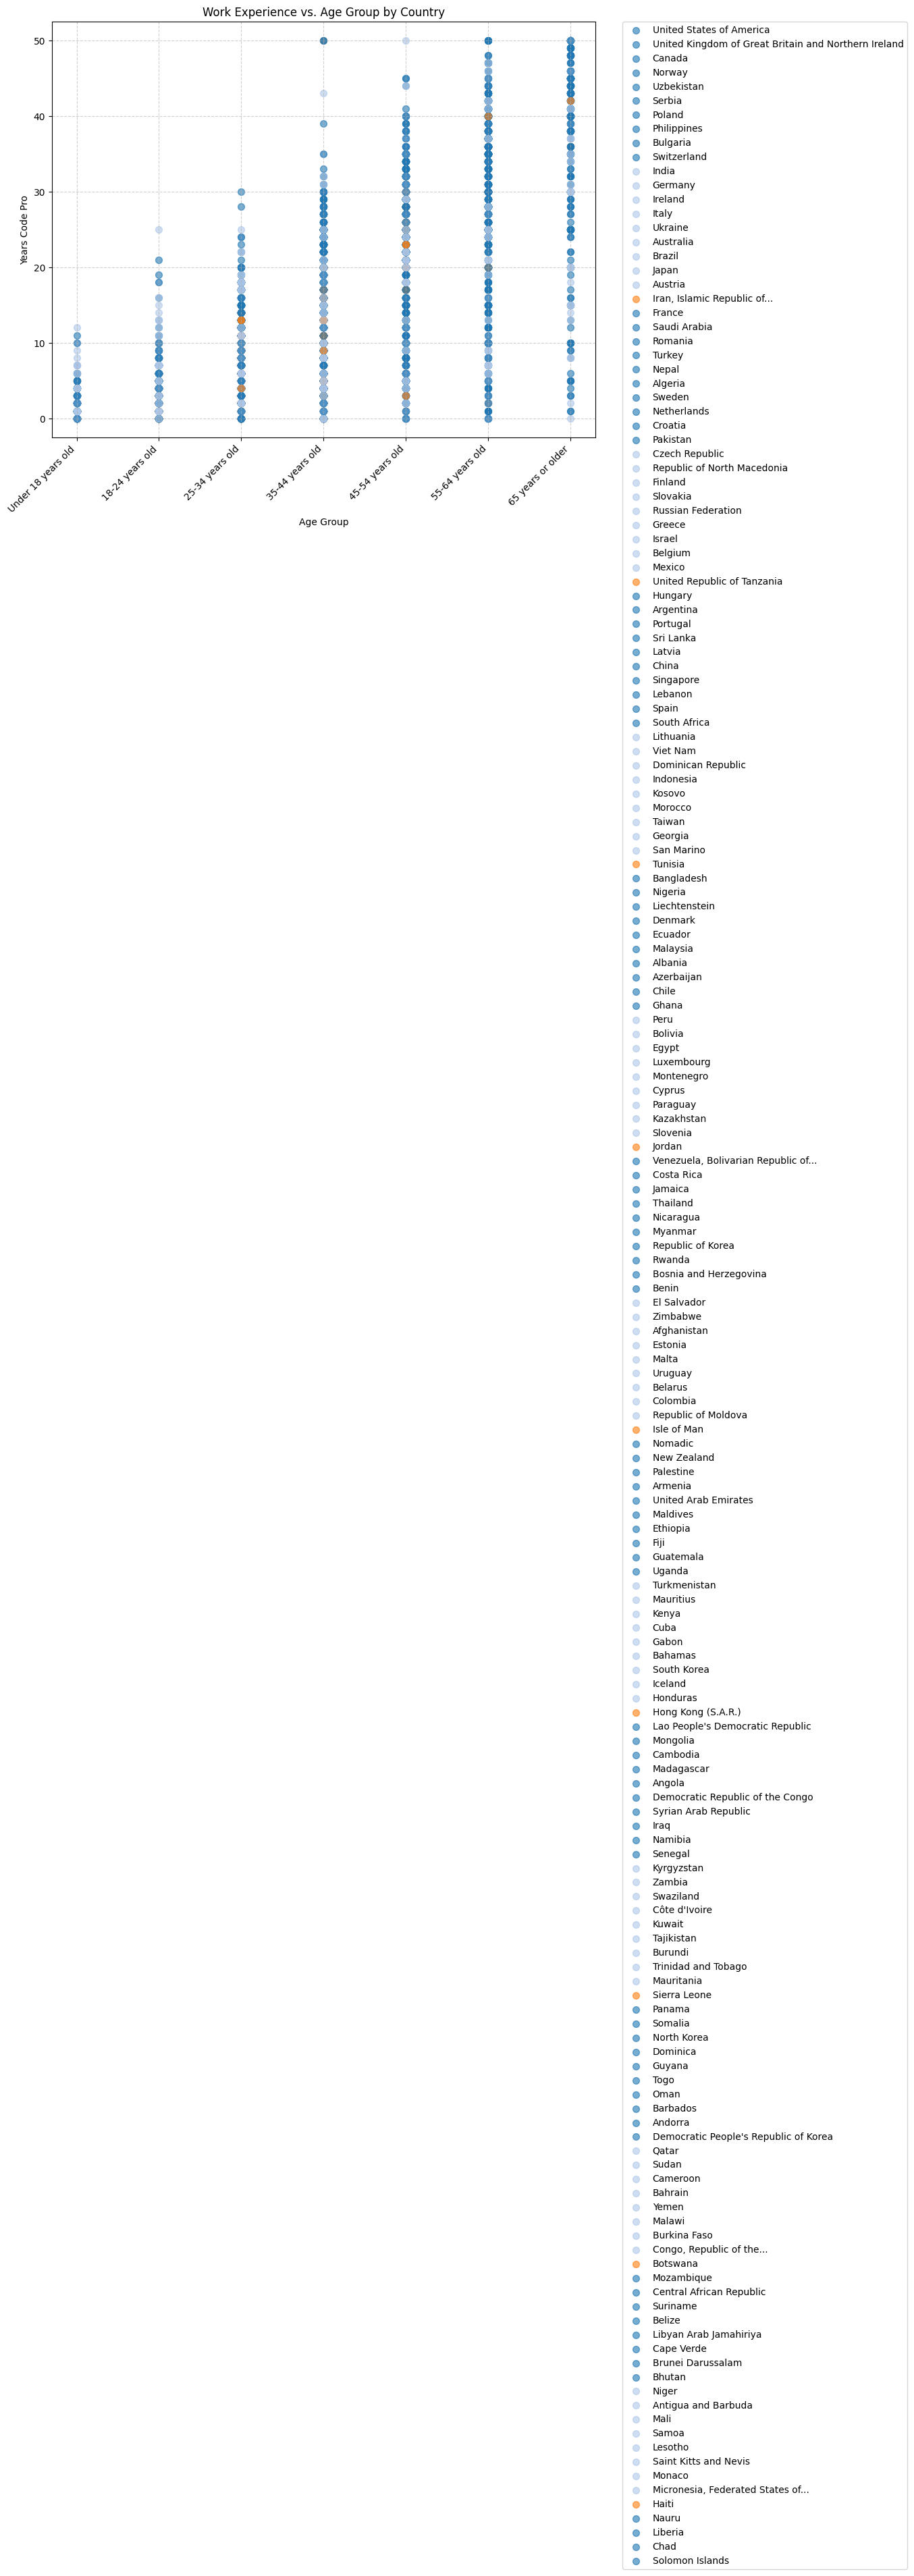

In [13]:
plt.figure(figsize=(14, 8))

# Get unique countries (consider top N countries if too many for clear visualization)
# For now, let's take all unique countries
countries = df['Country'].dropna().unique()

# Create a colormap for countries
# If there are too many countries, this might result in repetitive colors
colors = plt.get_cmap('tab20', len(countries))

i = 0
for country in countries:
    subset = df[(df['Country'] == country) & df['Age_numerical'].notna() & df['YearsCodePro_numeric'].notna()]
    if not subset.empty:
        plt.scatter(
            subset['Age_numerical'],
            subset['YearsCodePro_numeric'],
            label=country,
            alpha=0.6,
            s=50, # fixed size for markers
            color=colors(i % 20) # Cycle through colors if more than 20 countries
        )
    i += 1

plt.title('Work Experience vs. Age Group by Country')
plt.xlabel('Age Group')
plt.ylabel('Years Code Pro')
plt.xticks(ticks=list(age_mapping.values()), labels=list(age_mapping.keys()), rotation=45, ha='right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.subplots_adjust(right=0.7)
plt.tight_layout()
plt.show()


### Task 1: Exploring Relationships with Scatter Plots



#### 1. Scatter Plot for Age vs. Job Satisfaction



Visualize the relationship between respondents' age (`Age`) and job satisfaction (`JobSatPoints_6`). Use this plot to identify any patterns or trends.




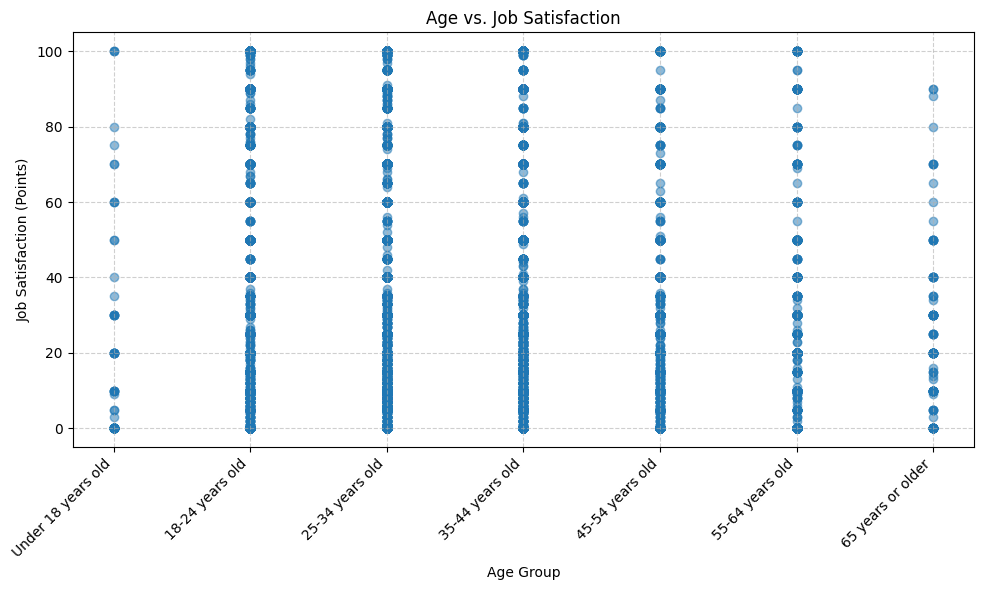

In [3]:
age_mapping = {
    'Under 18 years old': 0,
    '18-24 years old': 1,
    '25-34 years old': 2,
    '35-44 years old': 3,
    '45-54 years old': 4,
    '55-64 years old': 5,
    '65 years or older': 6
}

df['Age_numerical'] = df['Age'].map(age_mapping)

plt.figure(figsize=(10, 6))
plt.scatter(df['Age_numerical'], df['JobSatPoints_6'], alpha=0.5)
plt.title('Age vs. Job Satisfaction')
plt.xlabel('Age Group')
plt.ylabel('Job Satisfaction (Points)')
plt.xticks(ticks=list(age_mapping.values()), labels=list(age_mapping.keys()), rotation=45, ha='right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

#### 2. Scatter Plot for Compensation vs. Job Satisfaction


Explore the relationship between yearly compensation (`ConvertedCompYearly`) and job satisfaction (`JobSatPoints_6`) using a scatter plot.


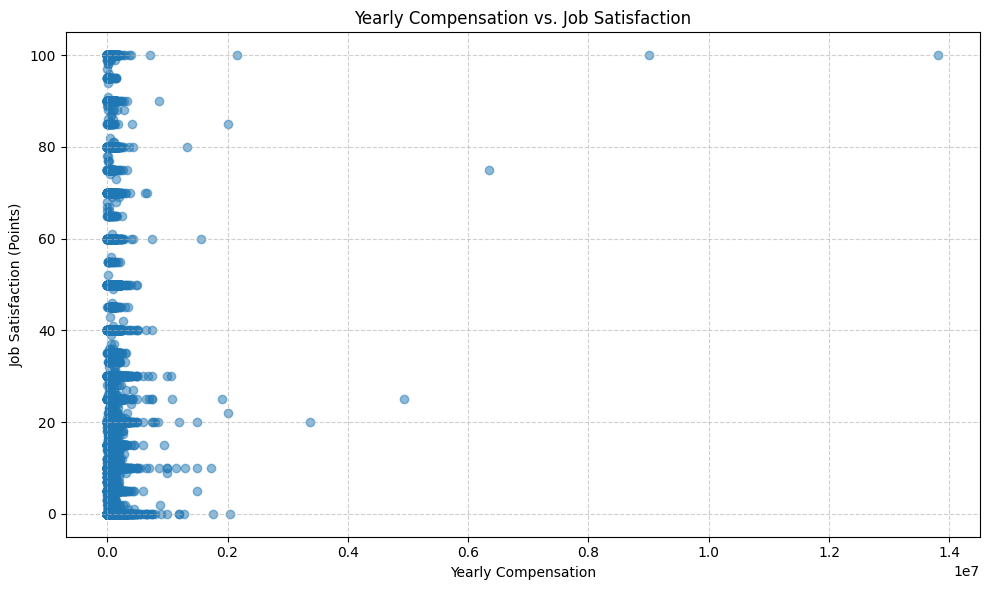

In [4]:
plt.figure(figsize=(10, 6))
plt.scatter(df['ConvertedCompYearly'], df['JobSatPoints_6'], alpha=0.5)
plt.title('Yearly Compensation vs. Job Satisfaction')
plt.xlabel('Yearly Compensation')
plt.ylabel('Job Satisfaction (Points)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### Task 2: Enhancing Scatter Plots


#### 1. Scatter Plot with Trend Line for Age vs. Job Satisfaction



Add a regression line to the scatter plot of Age vs. JobSatPoints_6 to highlight trends in the data.


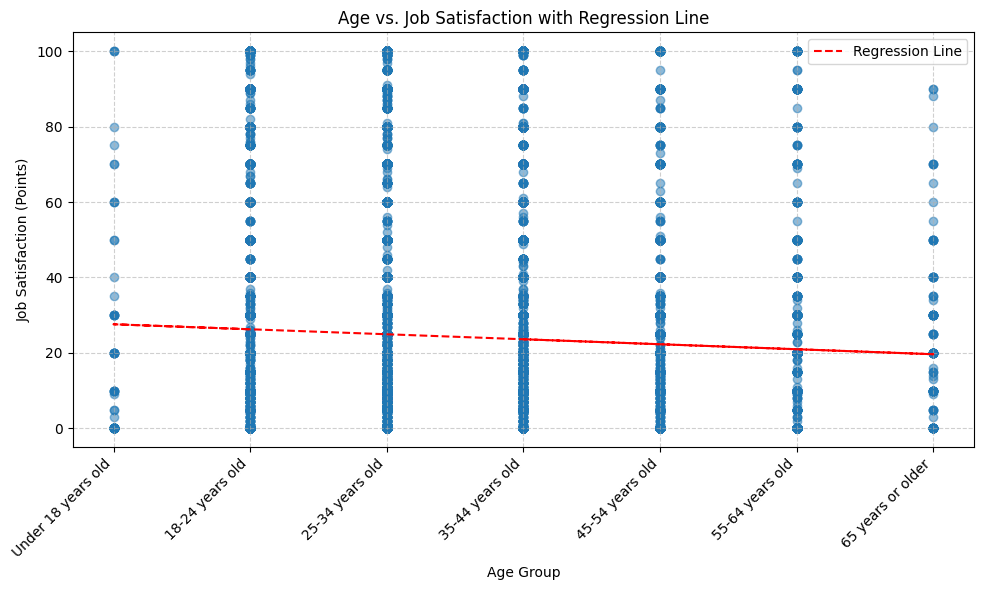

In [5]:
import numpy as np

# Drop rows with NaN in 'Age_numerical' or 'JobSatPoints_6' for regression calculation
df_filtered = df.dropna(subset=['Age_numerical', 'JobSatPoints_6'])

# Calculate the regression line
z = np.polyfit(df_filtered['Age_numerical'], df_filtered['JobSatPoints_6'], 1)
p = np.poly1d(z)

plt.figure(figsize=(10, 6))
plt.scatter(df['Age_numerical'], df['JobSatPoints_6'], alpha=0.5)
plt.plot(df_filtered['Age_numerical'], p(df_filtered['Age_numerical']), color='red', linestyle='--', label='Regression Line')
plt.title('Age vs. Job Satisfaction with Regression Line')
plt.xlabel('Age Group')
plt.ylabel('Job Satisfaction (Points)')
plt.xticks(ticks=list(age_mapping.values()), labels=list(age_mapping.keys()), rotation=45, ha='right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

#### 2. Scatter Plot for Age vs. Work Experience


Visualize the relationship between Age (`Age`) and Work Experience (`YearsCodePro`) using a scatter plot.


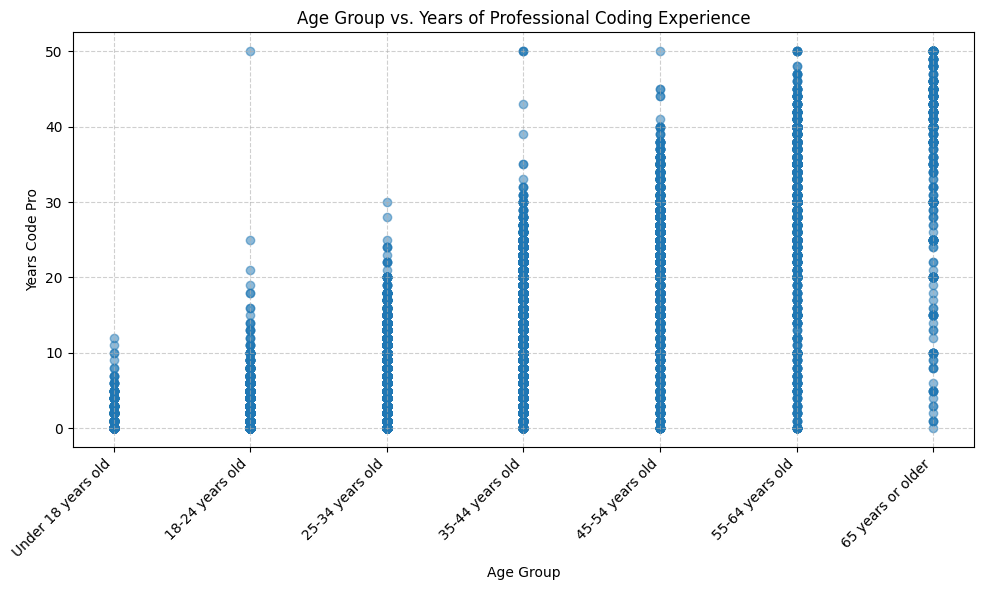

In [6]:
# Convert 'YearsCodePro' to numerical
# Replace 'Less than 1 year' with 0 and 'More than 50 years' with 50
# Then convert the column to numeric type, coercing errors to NaN
df['YearsCodePro_numeric'] = df['YearsCodePro'].replace('Less than 1 year', 0)
df['YearsCodePro_numeric'] = df['YearsCodePro_numeric'].replace('More than 50 years', 50)
df['YearsCodePro_numeric'] = pd.to_numeric(df['YearsCodePro_numeric'], errors='coerce')

# Drop rows where either 'Age_numerical' or 'YearsCodePro_numeric' is NaN
# This ensures that only complete data points are plotted
df_plot = df.dropna(subset=['Age_numerical', 'YearsCodePro_numeric'])

plt.figure(figsize=(10, 6))
plt.scatter(df_plot['Age_numerical'], df_plot['YearsCodePro_numeric'], alpha=0.5)
plt.title('Age Group vs. Years of Professional Coding Experience')
plt.xlabel('Age Group')
plt.ylabel('Years Code Pro')
plt.xticks(ticks=list(age_mapping.values()), labels=list(age_mapping.keys()), rotation=45, ha='right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### Task 3: Combining Scatter Plots with Additional Features


#### 1. Bubble Plot of Compensation vs. Job Satisfaction with Age as Bubble Size



Create a bubble plot to explore the relationship between yearly compensation (`ConvertedCompYearly`) and job satisfaction (`JobSatPoints_6`), with bubble size representing age.


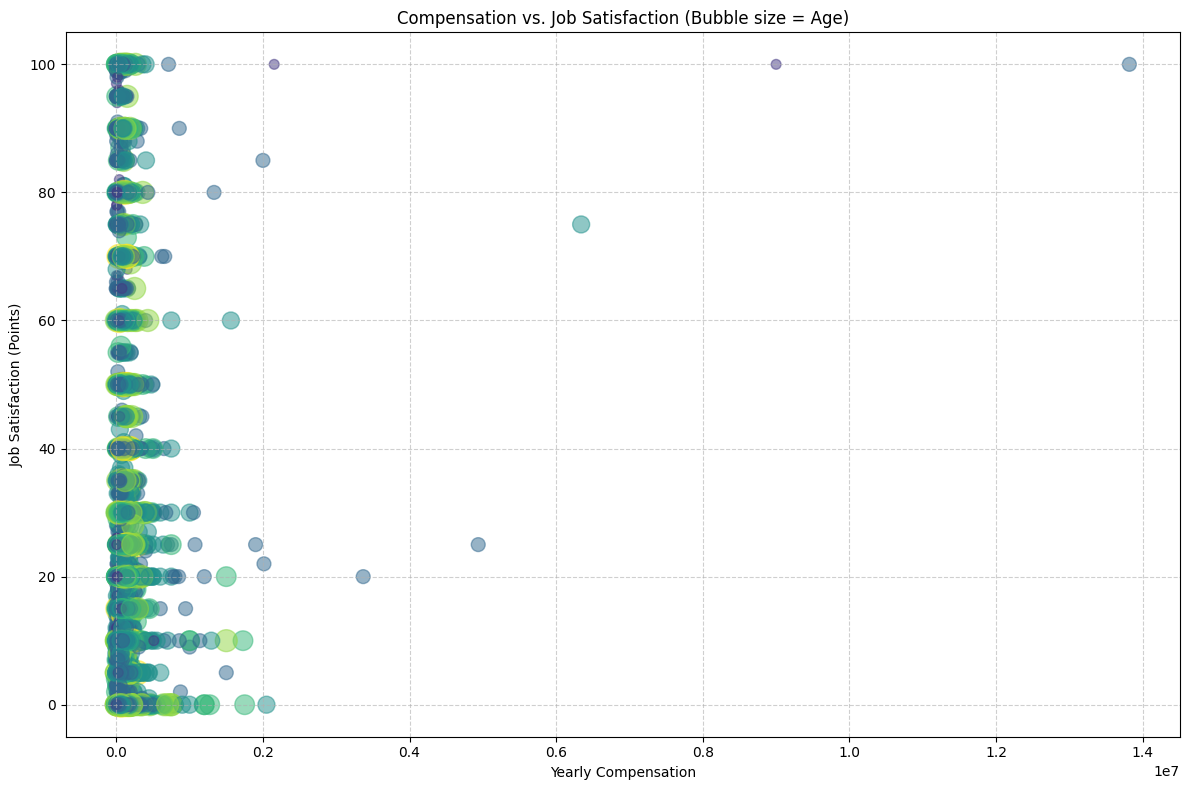

In [7]:
plt.figure(figsize=(12, 8))
# Scale Age_numerical for better bubble size representation
# You might need to adjust the scaling factor (e.g., *50) based on your data
plt.scatter(
    df['ConvertedCompYearly'],
    df['JobSatPoints_6'],
    s=df['Age_numerical'] * 50, # Scale age for bubble size
    alpha=0.5,
    c=df['Age_numerical'], # Color by age group
    cmap='viridis' # Choose a colormap
)
plt.title('Compensation vs. Job Satisfaction (Bubble size = Age)')
plt.xlabel('Yearly Compensation')
plt.ylabel('Job Satisfaction (Points)')
plt.grid(True, linestyle='--', alpha=0.6)

# Create a legend for bubble sizes (optional, but good for interpretation)
handles, labels = plt.gca().get_legend_handles_labels()
# You might need a more sophisticated legend for bubble sizes
# For simplicity, we'll omit a detailed size legend here or create a custom one if needed

plt.tight_layout()
plt.show()

#### 2. Scatter Plot for Popular Programming Languages by Job Satisfaction


Visualize the popularity of programming languages (`LanguageHaveWorkedWith`) against job satisfaction using a scatter plot. Use points to represent satisfaction levels for each language.


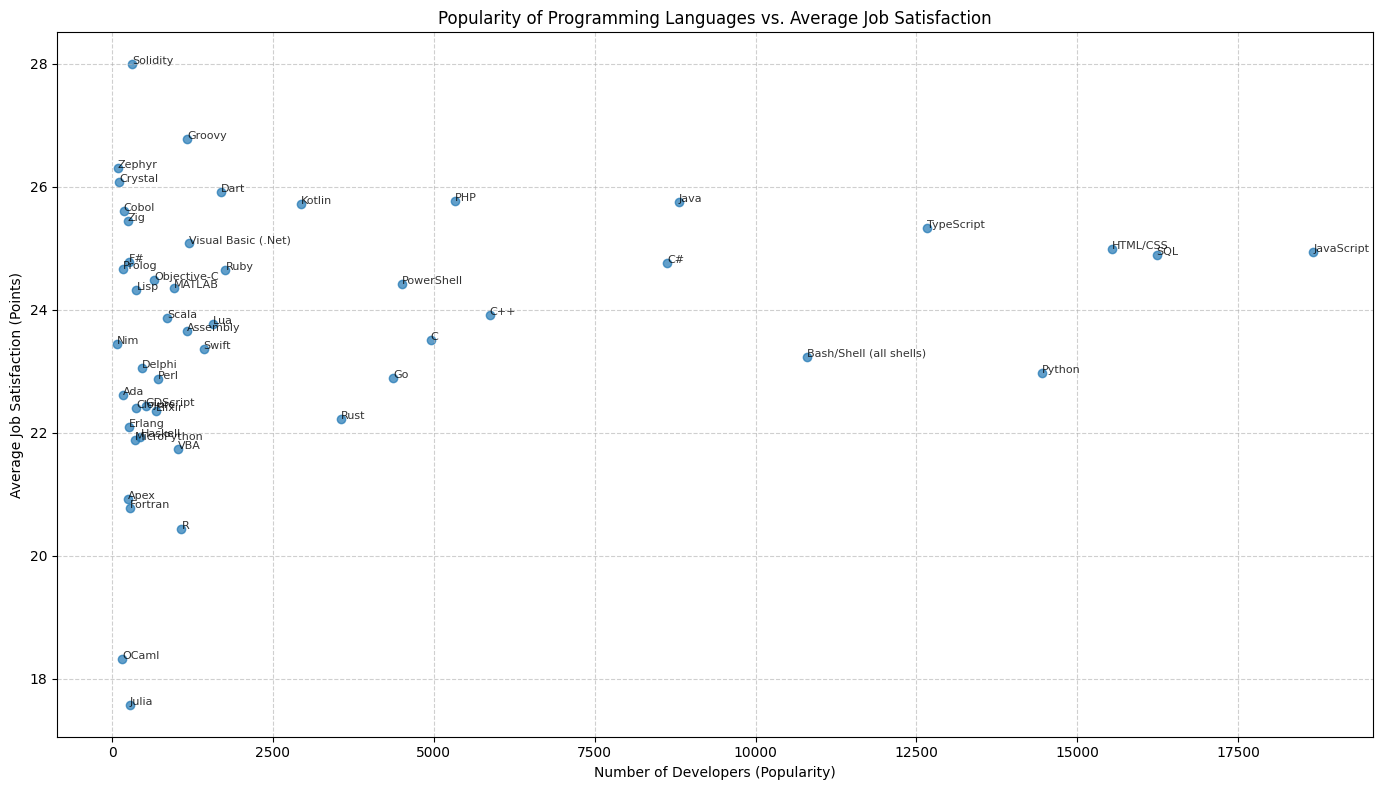

In [8]:
# Task 3.2: Scatter Plot for Popular Programming Languages by Job Satisfaction

# 1. Prepare the data for plotting
# Drop rows where LanguageHaveWorkedWith or JobSatPoints_6 is NaN
df_languages = df.dropna(subset=['LanguageHaveWorkedWith', 'JobSatPoints_6']).copy()

# Split the 'LanguageHaveWorkedWith' column into individual languages and explode the DataFrame
df_languages['Language'] = df_languages['LanguageHaveWorkedWith'].str.split(';')
df_exploded = df_languages.explode('Language')

# Strip whitespace from language names for clean grouping
df_exploded['Language'] = df_exploded['Language'].str.strip()

# Calculate the average job satisfaction and the count for each language
language_stats = df_exploded.groupby('Language').agg(
    avg_job_satisfaction=('JobSatPoints_6', 'mean'),
    popularity=('Language', 'count')
).reset_index()

# Sort by popularity to potentially focus on more common languages or for better visualization
language_stats = language_stats.sort_values(by='popularity', ascending=False)

# 2. Create the scatter plot
plt.figure(figsize=(14, 8))
plt.scatter(language_stats['popularity'], language_stats['avg_job_satisfaction'], alpha=0.7)

# Add labels for each point (language)
# To avoid overcrowding, consider labeling only the top N languages or adjusting font size
# For demonstration, we'll label all, but in practice, you might refine this.
for i, row in language_stats.iterrows():
    plt.text(row['popularity'], row['avg_job_satisfaction'], row['Language'], fontsize=8, alpha=0.8)

plt.title('Popularity of Programming Languages vs. Average Job Satisfaction')
plt.xlabel('Number of Developers (Popularity)')
plt.ylabel('Average Job Satisfaction (Points)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### Task 4: Scatter Plot Comparisons Across Groups


#### 1. Scatter Plot for Compensation vs. Job Satisfaction by Employment Type


Visualize the relationship between yearly compensation (`ConvertedCompYearly`) and job satisfaction (`JobSatPoints_6`), categorized by employment type (`Employment`). Use color coding or markers to differentiate between employment types.


/tmp/ipykernel_169/835420587.py:17: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


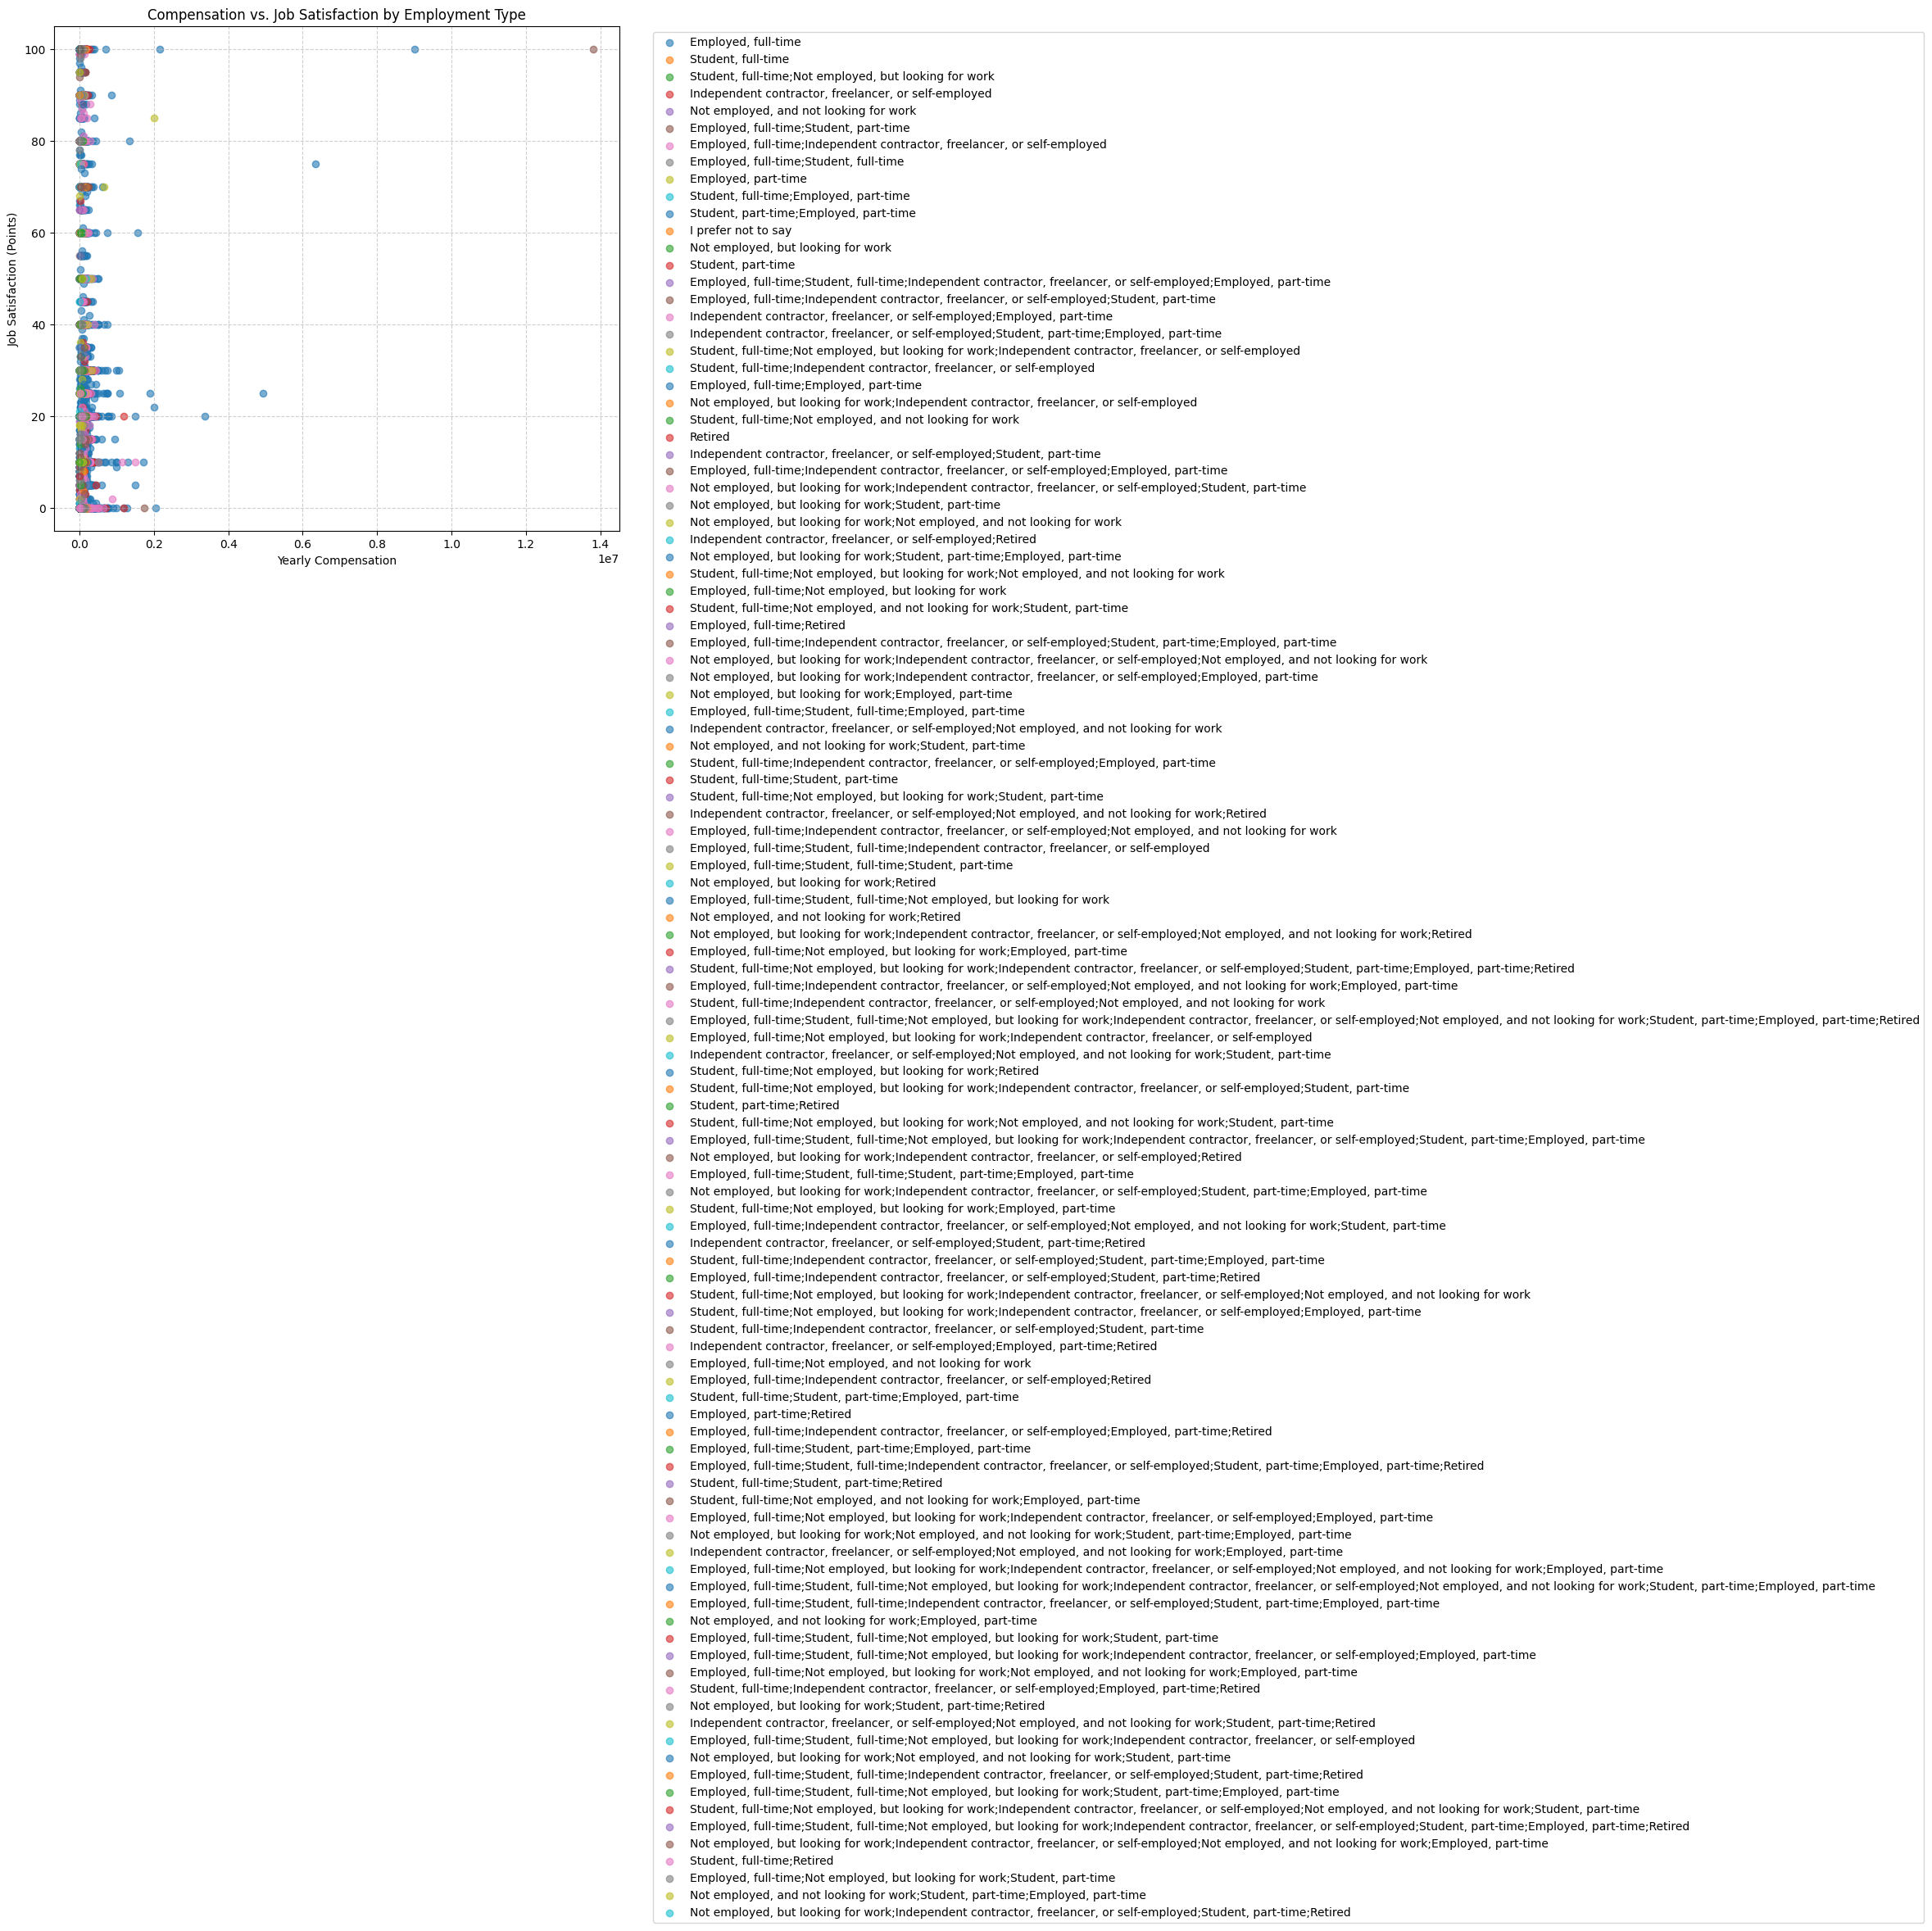

In [10]:
plt.figure(figsize=(12, 8))

# Get unique employment types
employment_types = df['Employment'].dropna().unique()

# Plot each employment type with a different color
for emp_type in employment_types:
    subset = df[df['Employment'] == emp_type]
    plt.scatter(subset['ConvertedCompYearly'], subset['JobSatPoints_6'], label=emp_type, alpha=0.6)

plt.title('Compensation vs. Job Satisfaction by Employment Type')
plt.xlabel('Yearly Compensation')
plt.ylabel('Job Satisfaction (Points)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') # Place legend outside plot
plt.subplots_adjust(right=0.7) # Adjust right margin to make space for the legend
plt.tight_layout()
plt.show()

#### 2. Scatter Plot for Work Experience vs. Age Group by Country


Compare work experience (`YearsCodePro`) across different age groups (`Age`) and countries (`Country`). Use colors to represent different countries and markers for age groups.


In [ ]:
## Write your code here

### Final Step: Review


With these scatter plots, you will have analyzed data relationships across multiple dimensions, including compensation, job satisfaction, employment types, and demographics, to uncover meaningful trends in the developer community.


### Summary


After completing this lab, you will be able to:
- Analyze how numerical variables relate across specific groups, such as employment types and countries.
- Use scatter plots effectively to represent multiple variables with color, size, and markers.
- Gain insights into compensation, satisfaction, and demographic trends using advanced scatter plot techniques.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


<!--## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|               
|2024-10-07|1.2|Madhusudan Moole|Reviewed and updated lab|                                                                                      
|2024-10-06|1.0|Raghul Ramesh|Created lab|-->


Copyright © IBM Corporation. All rights reserved.
